# Alpha Quest CTA Research

In [1]:
import os
import sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
blog_path = os.getcwd()
res_path  = os.path.abspath(os.path.join(blog_path, ".."))
repo_path = os.path.abspath(os.path.join(res_path, ".."))
data_path = os.path.join(repo_path, "data")

In [3]:
tool_path = os.path.join(repo_path, "src", "Tools")
sys.path.append(tool_path)

from AlphaQuestTools import AQTools

# AlphaQuest CTA Research Series #1 - Black Box Trend Following – Lifting the Veil 

In [4]:
fut_path   = os.path.join(data_path, "FuturesData", "PrepFuturesPX.parquet")
df_fut_raw = pd.read_parquet(path = fut_path, engine = "pyarrow")

In [5]:
idx_path = os.path.join(data_path, "TrendIndices", "TrendIndicesGuide.xlsx")

df_ticker = (pd.read_excel(
    io = idx_path, sheet_name = "IndexReplication").
    query("group == 'AlphaQuest'").
    assign(tmp = lambda x: x.ticker.str.replace(" 1", "1").str.replace(" ", "_").str.lower()))

In [6]:
tickers = df_ticker.tmp.drop_duplicates().sort_values().to_list()
df_fut_sliced = df_fut_raw.query("ticker == @tickers")

In [7]:
def _channel_breakout(df: pd.DataFrame, window: int = 50) -> pd.DataFrame:

    df_out = (
        df.sort_values("date")
        .assign(
            px_rtn    = lambda x: x.adj_val.pct_change(),
            high_close=lambda x: x.adj_val.rolling(window=window).max(),
            low_close=lambda x: x.adj_val.rolling(window=window).min(),
            signal=lambda x:
                np.where(x.adj_val == x.high_close, 1, 0)
                + np.where(x.adj_val == x.low_close, -1, 0),
        )
        .assign(
            signal=lambda x: x.signal.replace(0, np.nan).ffill(),
            lag_signal=lambda x: x.signal.shift(),
        )
    )

    return df_out

channel_window = 50

df_channel_breakout = (df_fut_sliced.groupby(
    "ticker").
    apply(_channel_breakout, channel_window).
    reset_index().
    drop(columns = ["level_1"]).
    assign(signal_rtn = lambda x: np.sign(x.lag_signal) * x.px_rtn))

In [8]:
def _ma_crossover(df: pd.DataFrame, small_window: int = 10, big_window: int = 100) -> pd.DataFrame:

    df_out = (df.sort_values(
        "date").
        assign(
            px_rtn     = lambda x: x.adj_val.pct_change(),
            small_ma   = lambda x: x.adj_val.rolling(window = small_window).mean(),
            big_ma     = lambda x: x.adj_val.rolling(window = big_window).mean(),
            signal     = lambda x: x.small_ma - x.big_ma,
            lag_signal = lambda x: x.signal.shift()))

    return df_out

small_window    = 10
big_window      = 100
df_ma_crossover = (df_fut_sliced.
    groupby("ticker").
    apply(_ma_crossover, small_window, big_window).
    reset_index().
    drop(columns = ["level_1"]).
    assign(signal_rtn = lambda x: np.sign(x.lag_signal) * x.px_rtn))

In [9]:
df_signal_rtn = (pd.concat([
    df_ma_crossover[["date", "ticker", "signal_rtn"]].assign(signal = "MaCrossover"),
    df_channel_breakout[["date", "ticker", "signal_rtn"]].assign(signal = "ChannelBreakout")]))

To keep consistency with their author's approach they've analyzed the returns calculaing the NAV of each strategy and then taking the daily difference in account value as the standard deviation. Therefore we'll do something similar. Since non-integer positions are being used the starting values are irrelevant. 

In [10]:
df_account_pnl = (df_signal_rtn.pivot(
    index = "date", columns = ["ticker", "signal"], values = "signal_rtn").
    apply(lambda x: np.cumprod(1 + x) * 100).
    diff())

They don't state which kind of standard deviation they are using although its likely exponentially-weighted. They do say that they target a 1% PnL and use a window of about 100 days. We'll also account for contemperanous vs lagged hedging.

In [11]:
df_ewma_lag = (df_account_pnl.apply(
    lambda x: 0.01 / x.ewm(span = 100, adjust = False).std()).
    shift().
    reset_index().
    melt(id_vars = [("date", "")], value_name = "weight").
    rename(columns = {("date", ""): "date"}).
    dropna().
    assign(method = "ewma_lag"))

df_ewma = (df_account_pnl.apply(
    lambda x: 0.01 / x.ewm(span = 100, adjust = False).std()).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "weight").
    rename(columns = {("date", ""): "date"}).
    dropna().
    assign(method = "ewma"))

In [12]:
df_weighted_rtn = (pd.concat([
    df_ewma_lag, df_ewma]).
    merge(right = df_signal_rtn, how = "inner", on = ["date", "ticker", "signal"]).
    assign(weighted_rtn = lambda x: x.weight * x.signal_rtn))

df_combined = (df_weighted_rtn[
    ["date", "signal", "method", "weighted_rtn"]].
    groupby(["date", "signal", "method"]).
    agg("mean").
    reset_index())

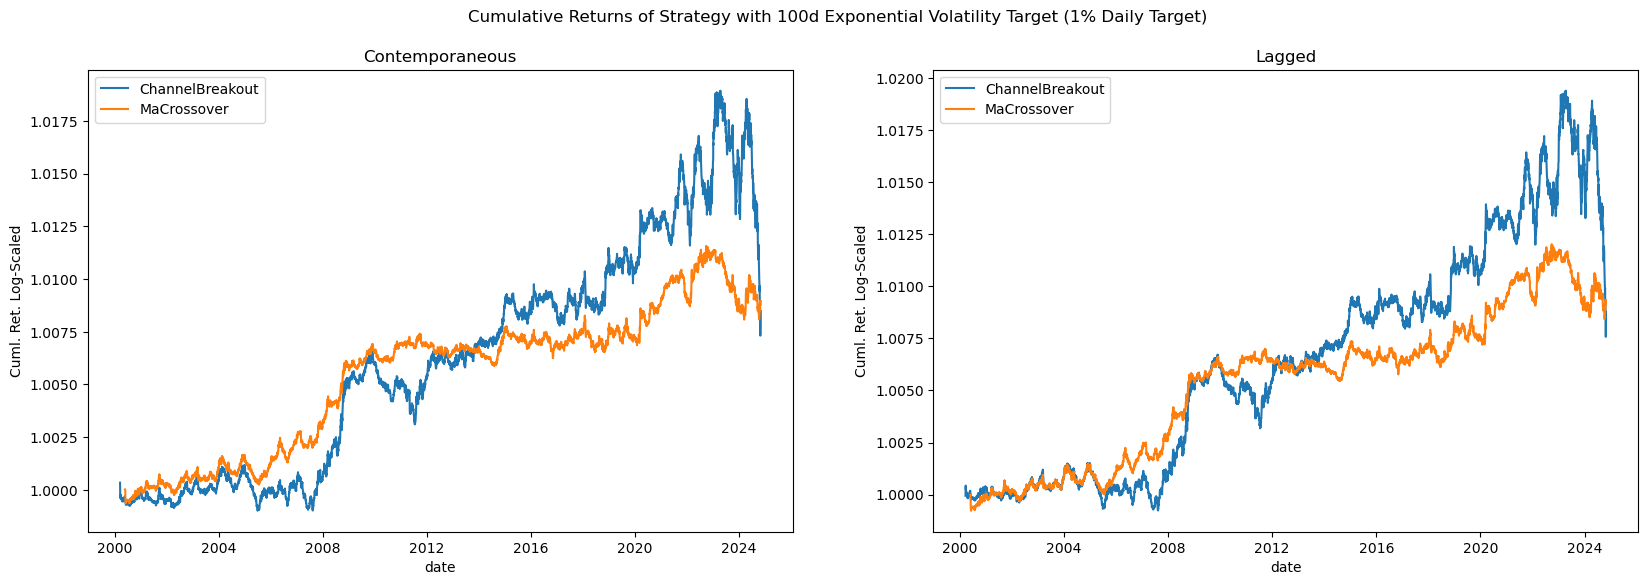

In [13]:
methods   = df_combined.method.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

method_renamer = {
    "ewma"    : "Contemporaneous",
    "ewma_lag": "Lagged"}

for method, ax in zip(methods, axes.flatten()): 

    (df_combined.query(
        "method == @method").
        rename(columns = {"signal": ""}).
        pivot(index = "date", columns = "", values = "weighted_rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = method_renamer[method]))

fig.suptitle("Cumulative Returns of Strategy with 100d Exponential Volatility Target (1% Daily Target)")
plt.show()

The volatility target for account differences isn't giving enough weights bring the gross return down. Therefore the same approach will be used but rather than volatliity targeting the PnL of the NAV the raw returns will be used. 

In [14]:
def vol_target(df_signal_rtn: pd.DataFrame, vol_target: int = 0.01) -> pd.DataFrame:

    df_wider = (df_signal_rtn.pivot(
        index = "date", columns = ["signal", "ticker"], values = "signal_rtn"))
    
    df_ewma = (df_wider.apply(
        lambda x: x * (vol_target / (x.ewm(span = 100, adjust = False).std()))).
        reset_index().
        melt(id_vars = [("date", "")]).
        rename(columns = {("date", ""): "date"}).
        drop(columns = ["ticker"]).
        groupby(["date", "signal"]).
        agg("mean").
        reset_index().
        assign(method = "ewma"))
    
    df_ewma_lag = (df_wider.apply(
        lambda x: x * (vol_target / (x.ewm(span = 100, adjust = False).std().shift()))).
        reset_index().
        melt(id_vars = [("date", "")]).
        rename(columns = {("date", ""): "date"}).
        drop(columns = ["ticker"]).
        groupby(["date", "signal"]).
        agg("mean").
        reset_index().
        assign(method = "ewma_lag"))
    
    df_combined_port = (pd.concat([
        df_ewma, df_ewma_lag]).
        dropna().
        rename(columns = {"value": "rtn"}).
        assign(target = vol_target))

    return df_combined_port

In [15]:
df_ports = pd.concat([
    vol_target(df_signal_rtn),
    vol_target(df_signal_rtn, 0.03)])

In [16]:
df_tmp_port = df_ports.query("target == 0.01")

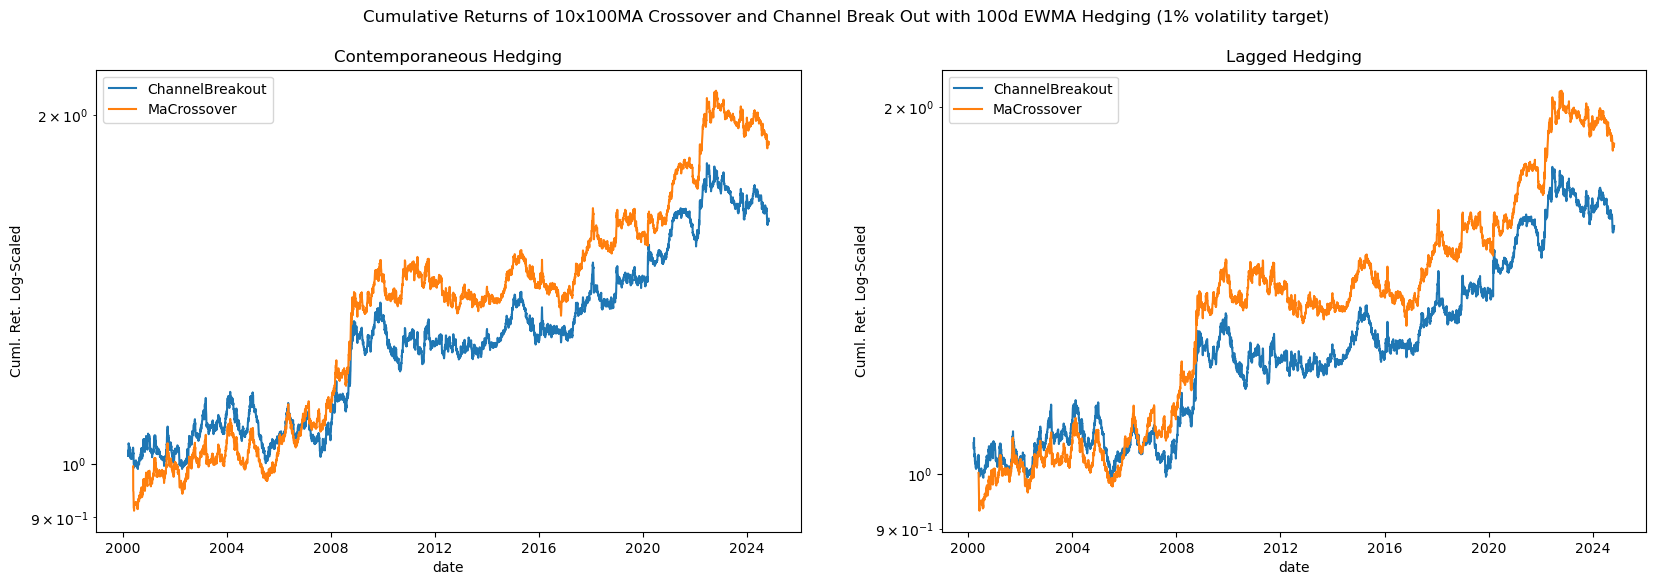

In [17]:
groups    = df_tmp_port.method.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (20,6))

for group, ax in zip(groups, axes.flatten()): 

    (df_tmp_port.query(
        "method == @group").
        rename(columns = {"signal": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = method_renamer[group] + " Hedging"))

fig.suptitle("Cumulative Returns of 10x100MA Crossover and Channel Break Out with 100d EWMA Hedging (1% volatility target)")
plt.show()

In [18]:
path     = r"A:\2026BlpAdHocData\Combined\PX"
cta_path = os.path.join(path, "hf_indices.parquet")
tre_path = os.path.join(path, "TrendIndices.parquet")

In [19]:
df_cta = (pd.read_parquet(
    path = cta_path, engine = "pyarrow").
    query("security == ['NEIXCTA Index']").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    dropna().
    pct_change())

In [20]:
df_trend = (pd.read_parquet(
    path = tre_path, engine = "pyarrow").
    query("security == 'NEIXCTAT Index'").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change())

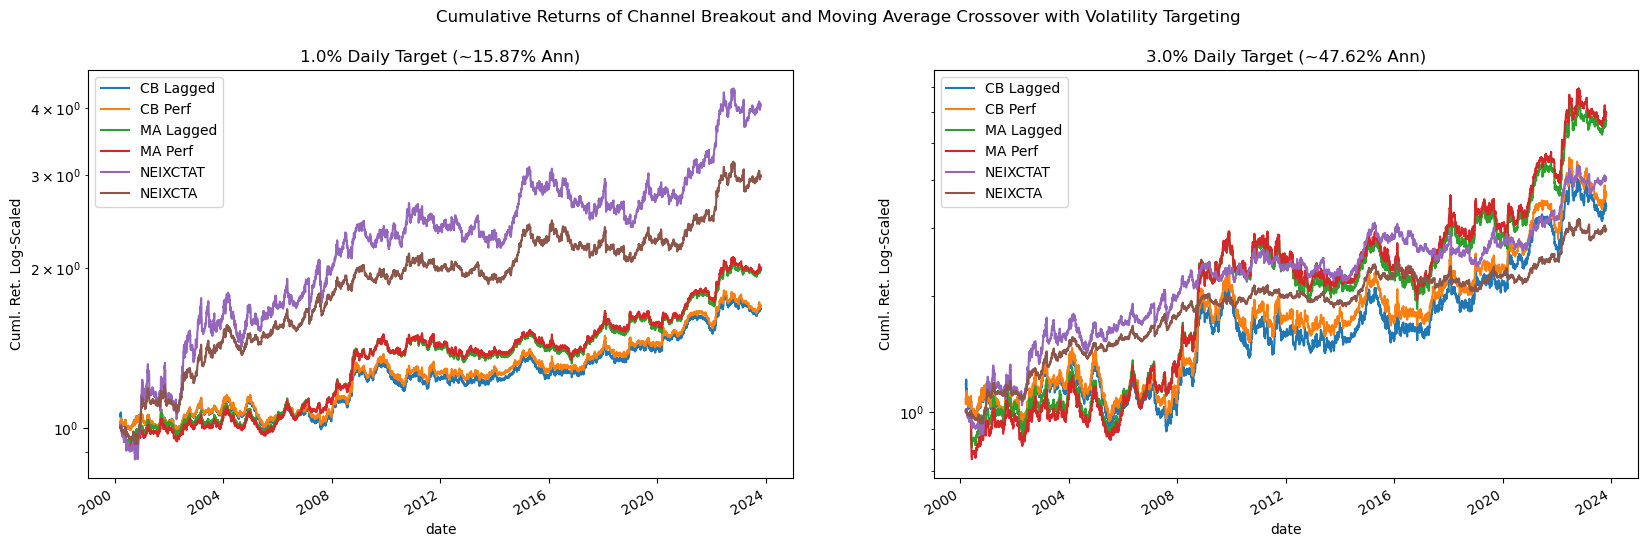

In [21]:
targets = df_ports.target.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(targets), figsize = (20,6))

for target, ax in zip(targets, axes.flatten()): 

    df_combined = (df_ports.query(
        "target == @target").
        assign(
            date = lambda x: pd.to_datetime(x.date),
            name = lambda x: 
                np.where(x.signal == "ChannelBreakout", "CB", "MA") + 
                " " + 
                np.where(x.method == "ewma", "Perf", "Lagged")).
        pivot(index = "date", columns = "name", values = "rtn").
        merge(right = df_trend, how = "inner", on = ["date"]).
        merge(right = df_cta, how = "inner", on = ["date"]).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{}% Daily Target (~{}% Ann)".format(target * 100, np.round(target * 100 * np.sqrt(252), 2))))

fig.suptitle("Cumulative Returns of Channel Breakout and Moving Average Crossover with Volatility Targeting")
plt.show()

In [22]:
renamer = {
    "ChannelBreakout": "CB",
    "MaCrossover"    : "MA",
    "ewma"           : "Perf",
    "ewma_lag"       : "Lag"}

df_port = (df_ports.query(
    "target == 0.03").
    replace(renamer).
    assign(
        date = lambda x: pd.to_datetime(x.date),
        name = lambda x: x.signal + " " + x.method).
    pivot(index = "date", columns = "name", values = "rtn").
    dropna())

In [23]:
df_combined = (df_port.merge(
    right = df_trend, how = "inner", on = ["date"]).
    merge(right = df_cta, how = "inner", on = ["date"]))

In [24]:
AQTools().get_perform_results(df_combined)

,CAGR,MaxDD,Ann. Vol.,Ann. Rtn / MaxDD,Sharpe
variable,,,,,
CB Lag,0.049893,-0.256498,0.012212,0.256995,0.340038
CB Perf,0.052952,-0.266652,0.011726,0.252292,0.361407
MA Lag,0.077167,-0.189394,0.012374,0.481888,0.464611
MA Perf,0.080134,-0.204893,0.012003,0.453076,0.487189
NEIXCTAT,0.062012,-0.229885,0.008073,0.289219,0.518779
NEIXCTA,0.047444,-0.165011,0.005150,0.292252,0.589861
